# From zero to neural networks

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
import numpy as np

## The McCulloch–Pitts neuron
<p align="center">
  <img src="images/threshold-neuron.png" width="440" alt="McCulloch-Pitts neuron"/>
  &nbsp;&nbsp;
  <img src="images/mark-i-perceptron.png" width="230" alt="Mark I Perceptron"/>
</p>

## Matrix multiplication (the dot product)

The weighted sum above is just a **dot product**, and the language of neural
networks is **matrix multiplication**. If $\mathbf{x}$ describes one individual
(e.g. age, height, weight) and $\boldsymbol{\beta}$ holds the effect/importance
of each feature, then stacking many individuals into a matrix $\mathbf{A}$ gives
the familiar **linear model**:

$$
\mathbf{x} = \begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{bmatrix},
\qquad
\boldsymbol{\beta} = \begin{bmatrix} \beta_0 \\ \beta_1 \\ \vdots \\ \beta_p \end{bmatrix},
\qquad
\mathbf{A} = \begin{bmatrix}
1 & x_{1,1} & \cdots & x_{1,p} \\
1 & x_{2,1} & \cdots & x_{2,p} \\
\vdots & \vdots & \ddots & \vdots \\
1 & x_{n,1} & \cdots & x_{n,p}
\end{bmatrix},
\qquad
\mathbf{y} = \mathbf{A}\boldsymbol{\beta} + \boldsymbol{\varepsilon}
$$

Let's build exactly this in PyTorch: random data `X`, random weights `w`, a bias
`b`, and some noise.

In [2]:
num_points = 20
num_features = 3
X = torch.rand(num_points, num_features)
print(X)
w = torch.rand(num_features)
print(w)
b = torch.rand(1)
print(b)
y = torch.matmul(X, w) + b + torch.randn(num_points)
y

tensor([[0.4739, 0.3520, 0.5526],
        [0.7558, 0.3869, 0.4010],
        [0.7964, 0.2900, 0.8551],
        [0.0482, 0.5258, 0.1881],
        [0.7513, 0.7168, 0.2474],
        [0.4431, 0.3256, 0.6681],
        [0.7057, 0.1056, 0.3376],
        [0.3475, 0.6622, 0.8576],
        [0.1737, 0.9432, 0.5461],
        [0.1935, 0.7269, 0.9537],
        [0.0506, 0.4454, 0.1290],
        [0.4558, 0.7632, 0.2187],
        [0.3874, 0.0630, 0.3087],
        [0.2107, 0.0495, 0.0297],
        [0.0403, 0.1914, 0.1189],
        [0.5120, 0.5725, 0.3891],
        [0.4956, 0.6769, 0.2183],
        [0.5658, 0.8582, 0.6755],
        [0.4034, 0.8394, 0.5860],
        [0.6042, 0.2647, 0.1639]])
tensor([0.7864, 0.6430, 0.4747])
tensor([0.8258])


tensor([2.2846, 2.0452, 1.8486, 2.1007, 3.7818, 0.8717, 2.4005, 2.5869, 1.3621, 1.0374, 1.5217, 2.4323, 0.3813, 1.2141, 1.8192, 4.1729, 1.9240, 1.8894, 1.9440, 4.1475])

## The McCulloch–Pitts neuron in code

Here is the neuron as a plain function: take the dot product of `weights` and
`inputs`, then apply the hard threshold.

In [3]:
def mcculloch_pitts_neuron(weights, inputs):
    weighted_sum = torch.dot(weights, inputs)
    output = torch.where(weighted_sum > 0, torch.tensor(1), torch.tensor(0))
    return output


# Define the weights and inputs
weights = torch.tensor([0.5, -0.5])
inputs = torch.tensor([1.0, 1.0])

# Compute the output of the neuron
output = mcculloch_pitts_neuron(weights, inputs)
print("Output of the McCulloch-Pitts neuron:", output)

Output of the McCulloch-Pitts neuron: tensor(0)


## Writing the neuron as a class (it's the same thing)

In [4]:
class McCullochPittsNeuron(torch.nn.Module):
    def __init__(self, weights, threshold):
        super(McCullochPittsNeuron, self).__init__()
        self.weights = torch.tensor(weights, dtype=torch.float32)
        self.threshold = threshold

    def forward(self, x):
        # Compute the weighted sum of inputs
        weighted_sum = torch.dot(x, self.weights)

        # Output 1 if the weighted sum is greater than or equal to the threshold, else output 0
        output = torch.where(
            weighted_sum >= self.threshold, torch.tensor(1), torch.tensor(0)
        )

        return output


# Example usage
# Define weights and threshold
weights = [0.5, -0.5]
threshold = 0

# Create a McCulloch-Pitts neuron
neuron = McCullochPittsNeuron(weights, threshold)

# Input example
input_data = torch.tensor([1.0, 0.0])

# Get the output of the neuron
output = neuron(input_data)

print("Output:", output.item())  # Output: 1 if the weighted sum >= threshold, else 0


Output: 1


## What are the issues? Why do we need more?

A single threshold unit draws a single straight line. That's enough to separate
**AND** and **OR**, but **XOR** is *not linearly separable* — no single line can
split it. To solve problems like this we need to (a) **stack** units into layers
and (b) **learn** the weights automatically instead of setting them by hand,
using a **loss function** and **backpropagation**.

<p align="center">
  <img src="images/logic-gates-xor.png" width="680" alt="AND, OR, XOR and the training loop"/>
</p>
<p align="center">
  <img src="images/and-or-xor.jpg" width="680" alt="AND, OR, XOR and the training loop"/>
</p>



## How do we perform learning?

**Hebbian learning** (Hopfield network 1982)

$$w = x \otimes x^{T} - I,$$

which in PyTorch reads:

```python
weights = torch.outer(states, states.T)
outer.fill_diagonal(weights, 0)
```

Hopfield networks gave us a model of how memory can store information, which served its use in both biology and computer science. 

## Let's start with linear regression

The simplest useful model: fit a straight line $y = wx + b$. First, just look at
the data and one *random* (untrained) prediction line.

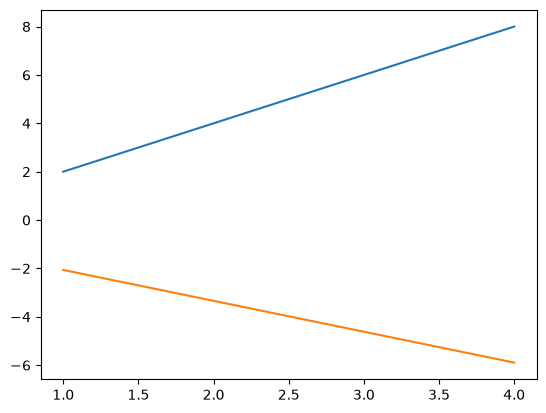

In [5]:
# Sample data
X = torch.tensor([[1.0], [2.0], [3.0], [4.0]])  # Input data
y = torch.tensor([[2.0], [4.0], [6.0], [8.0]])  # Target data
# Model parameters
input_size = 1  # Input dimension
output_size = 1  # Output dimension
weights = torch.randn(input_size, output_size)  # random normal
bias = torch.randn(output_size)
prediction = torch.mm(X, weights) + bias  # dot product

plt.plot(X.detach(), y.detach())
plt.plot(X.detach(), prediction.detach())

If we draw **100 different random** weight/bias combinations, we get 100 different
lines — almost all of them bad. "Training" is the process of searching this space
for the line that fits.

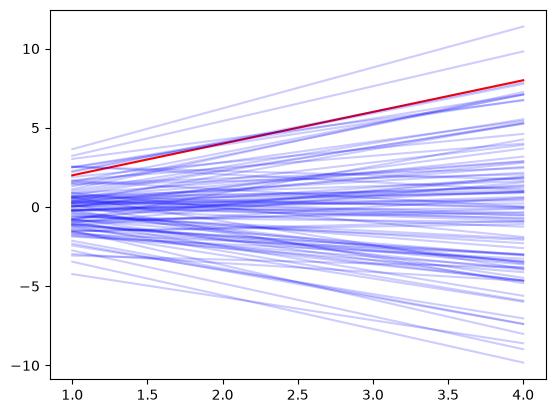

In [6]:
plt.plot(X.detach(), y.detach(), color="red")

for i in range(100):
    weights = torch.randn(input_size, output_size)
    bias = torch.randn(output_size)
    prediction = torch.mm(X, weights) + bias

    plt.plot(X.detach(), prediction.detach(), color="blue", alpha=0.2)

## We made part of a neural network!

That linear unit — inputs, weights, a bias — *is* a single layer of a neural
network. Stack a few of them with non-linearities in between and you have the
familiar input → hidden → output picture.

<p align="center">
  <img src="images/neural-network-partial.png" width="420" alt="A small neural network"/>
</p>

## Brief note — differentiation

To learn automatically we need to know *which way* to nudge each weight. That's a
**derivative**: the slope of the loss with respect to a parameter. Recall the
definition of a derivative as the limit of the slope between two nearby points:

$$\text{slope} = \frac{\Delta y}{\Delta x} = \frac{f(x+h) - f(x)}{h}$$

<p align="center">
  <img src="images/differentiation.png" width="560" alt="Differentiation as a slope"/>
</p>

## Autodiff — the hero of AI

We never compute these derivatives by hand. **Automatic differentiation** applies
the chain rule mechanically over the computation graph. 

Consider:

$$a = 4,\quad b = 3,\quad c = a + b,\quad d = a \cdot c.$$

What is $\partial d / \partial a$? Working it through with the product and chain
rules gives $\partial d/\partial a = 2a + b = 2\cdot 4 + 3 = 11$.

<p align="center">
  <img src="images/autodiff-chain-rule.png" width="300" alt="Chain rule derivation"/>
  &nbsp;&nbsp;
  <img src="images/autodiff-graph.png" width="470" alt="Autodiff computation graph"/>
</p>

PyTorch does all of this for us. Set `requires_grad=True`, build the expression,
call `.backward()`, and read `a.grad` — it should print **11.0**.

In [7]:
# Define variables with requires_grad=True to track computation history
a = torch.tensor(4.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)
# Define equations
c = a + b
d = a * c

# Compute gradients
d.backward()

# Access gradient of d w.r.t. a
d_da = a.grad

print("Gradient of d with respect to a:", d_da.item())

Gradient of d with respect to a: 11.0


## What if a function is not differentiable?

$$f(x) - f(x_0) \ge c\,(x - x_0), \qquad f : I \to \mathbb{R},$$

Essentially a set of gradients that captures the
possible slope of a function at a point where
it's not differentiable.

ReLU function, which is defined as $f(x) = \max(0, x)$, is not differentiable at $x = 0$. 

However, it's still convex, and the subgradient at $x = 0$ is any value between 0 and 1.

## What if I want to use discrete values?

Hard thresholds and discrete choices have zero gradient almost everywhere, which
breaks backpropagation. Two common tricks get around this:

- **Straight-through estimator (STE)** — use the hard (discrete) value on the
  forward pass, but pretend it was the identity on the backward pass so gradients
  can flow.

  <p align="center">
  <img src="images/straight-through-estimator.png" width="620" alt="Straight-through estimator"/>
</p>

- **Gumbel-softmax trick** — replace a hard categorical sample with a smooth,
  temperature-controlled ($\lambda$) relaxation that *is* differentiable.


<p align="center">
  <img src="images/gumbel-softmax.png" width="360" alt="Gumbel softmax trick"/>
</p>

## The loss function

A **loss function** measures how far the model's predictions are from the targets
it *should* produce. Training is nothing more than **minimising this "wrongness"**.

### Examples

$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} |\,y_i - \hat{y}_i\,|$$

$$\text{Cross Entropy} = -\frac{1}{n}\sum_{i=1}^{n}\big(y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i)\big)$$

$$\text{Hinge Loss} = \frac{1}{n}\sum_{i=1}^{n} \max(0,\, 1 - y_i \cdot \hat{y}_i)$$

We'll use **MSE** for regression and **cross entropy** for classification below.

## OK, let's train our linear model

Now we put the pieces together: forward pass → MSE loss → `loss.backward()` for
gradients → manually nudge the weights *downhill* by the learning rate → zero the
gradients and repeat. The data follows $y = 2x$, so the weight should converge to
**2** and the bias to **0**.

In [8]:
# Sample data
X = torch.tensor([[1.0], [2.0], [3.0], [4.0]])  # Input data
y = torch.tensor([[2.0], [4.0], [6.0], [8.0]])  # Target data

# Model parameters
input_size = 1  # Input dimension
output_size = 1  # Output dimension
weights = torch.randn(input_size, output_size, requires_grad=True)
bias = torch.randn(output_size, requires_grad=True)

# Hyperparameters
learning_rate = 0.01
num_epochs = 5000

# Training loop
for epoch in range(num_epochs):
    # Forward pass
    outputs = torch.mm(X, weights) + bias  # Dot product + bias
    loss = torch.mean((outputs - y) ** 2)  # Mean Squared Error loss

    # Backward pass
    loss.backward()

    # Update weights and bias
    with torch.no_grad():
        weights -= learning_rate * weights.grad
        bias -= learning_rate * bias.grad

        # Manually zero the gradients after updating weights
        weights.grad.zero_()
        bias.grad.zero_()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}")


print(weights, bias)


Epoch [100/5000], Loss: 0.0004
Epoch [200/5000], Loss: 0.0002
Epoch [300/5000], Loss: 0.0001
Epoch [400/5000], Loss: 0.0001
Epoch [500/5000], Loss: 0.0000
Epoch [600/5000], Loss: 0.0000
Epoch [700/5000], Loss: 0.0000
Epoch [800/5000], Loss: 0.0000
Epoch [900/5000], Loss: 0.0000
Epoch [1000/5000], Loss: 0.0000
Epoch [1100/5000], Loss: 0.0000
Epoch [1200/5000], Loss: 0.0000
Epoch [1300/5000], Loss: 0.0000
Epoch [1400/5000], Loss: 0.0000
Epoch [1500/5000], Loss: 0.0000
Epoch [1600/5000], Loss: 0.0000
Epoch [1700/5000], Loss: 0.0000
Epoch [1800/5000], Loss: 0.0000
Epoch [1900/5000], Loss: 0.0000
Epoch [2000/5000], Loss: 0.0000
Epoch [2100/5000], Loss: 0.0000
Epoch [2200/5000], Loss: 0.0000
Epoch [2300/5000], Loss: 0.0000
Epoch [2400/5000], Loss: 0.0000
Epoch [2500/5000], Loss: 0.0000
Epoch [2600/5000], Loss: 0.0000
Epoch [2700/5000], Loss: 0.0000
Epoch [2800/5000], Loss: 0.0000
Epoch [2900/5000], Loss: 0.0000
Epoch [3000/5000], Loss: 0.0000
Epoch [3100/5000], Loss: 0.0000
Epoch [3200/5000]

### The same thing, the idiomatic way

By hand it's instructive, but in practice we let PyTorch manage the parameters
(`nn.Linear`), the loss (`nn.MSELoss`) and the update rule (`optim.SGD`). This is
exactly the same optimisation as above, just with less boilerplate — and it again
recovers weight ≈ 2, bias ≈ 0.

In [9]:
# Define a simple linear regression model
class LinearRegression(nn.Module):
    def __init__(self, input_size, output_size):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(input_size, output_size)

    def forward(self, x):
        return self.linear(x)


# Initialize model
input_size = 1  # Input dimension
output_size = 1  # Output dimension
model = LinearRegression(input_size, output_size)

# Define loss function and optimizer
criterion = nn.MSELoss()  # Mean Squared Error loss
optimizer = optim.SGD(
    model.parameters(), lr=0.1
)  # Stochastic Gradient Descent optimizer

# Training loop
num_epochs = 1000
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(X)
    loss = criterion(outputs, y)

    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}")

print(model.linear.weight)
print(model.linear.bias)


Epoch [100/1000], Loss: 0.0001
Epoch [200/1000], Loss: 0.0000
Epoch [300/1000], Loss: 0.0000
Epoch [400/1000], Loss: 0.0000
Epoch [500/1000], Loss: 0.0000
Epoch [600/1000], Loss: 0.0000
Epoch [700/1000], Loss: 0.0000
Epoch [800/1000], Loss: 0.0000
Epoch [900/1000], Loss: 0.0000
Epoch [1000/1000], Loss: 0.0000
Parameter containing:
tensor([[2.]], requires_grad=True)
Parameter containing:
tensor([1.1861e-07], requires_grad=True)


## A neural network is *nothing* more than stacking linear models

Chain linear layers together, insert a non-linearity (here **ReLU**) between them,
and you have a neural network. Without the non-linearity, stacked linear layers
would collapse back into a single linear layer — the activation is what gives the
network its expressive power.

<p align="center">
  <img src="images/stacked-linear-models.png" width="360" alt="Stacking linear models into a network"/>
</p>

In [10]:
# Define a simple linear model
class LinearModel(nn.Module):
    def __init__(self, input_size, output_size):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(input_size, output_size)

    def forward(self, x):
        return self.linear(x)


# Define a neural network by stacking linear models
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(NeuralNetwork, self).__init__()
        self.layer1 = LinearModel(input_size, hidden_size)
        self.layer2 = LinearModel(hidden_size, output_size)

    def forward(self, x):
        x = self.layer1(x)
        x = torch.relu(x)  # Applying activation
        x = self.layer2(x)
        return x

## An archetype — MNIST

Time for real data. **MNIST** is 70,000 handwritten digit images (28×28 pixels,
10 classes) — the "hello world" of deep learning. We configure the device and
hyperparameters and load the dataset with `torchvision`.

In [11]:
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
input_size = 784  # 28 x 28 pixels
num_classes = 10
num_epochs = 5
batch_size = 100
learning_rate = 0.001

# MNIST dataset
train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, transform=transforms.ToTensor(), download=True
)

test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, transform=transforms.ToTensor()
)

# Data loader
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset, batch_size=batch_size, shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, batch_size=batch_size, shuffle=False
)


Let's peek at a single training image.

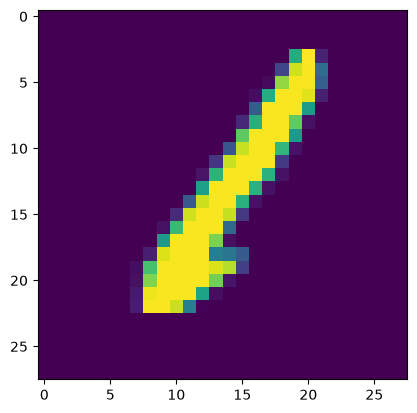

In [12]:
# Get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
plt.imshow(images[5, 0, :, :])


And a whole batch at once using `torchvision.utils.make_grid`.

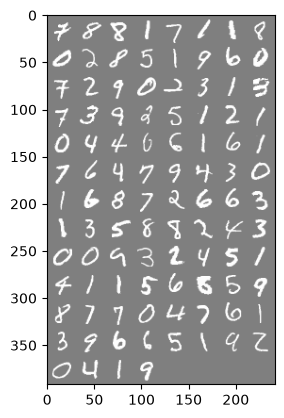

In [13]:
# Function to show an image
def imshow(img):
    img = img / 2 + 0.5  # Unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# Show images
imshow(torchvision.utils.make_grid(images))


## Putting it all together — training on MNIST

Everything so far — a stack of linear layers, ReLU activations, a loss function,
autodiff and an optimiser — combines into a small fully-connected network. We
flatten each 28×28 image to a 784-vector, pass it through one hidden layer, and
classify into 10 digits with **cross-entropy** loss and the **Adam** optimiser.

After a few epochs it reaches **~98% accuracy** on the held-out test set.

In [14]:
# Fully connected neural network with one hidden layer
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out


hidden_size = 256
model = NeuralNet(input_size, hidden_size, num_classes).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Train the model
total_step = len(train_loader)
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i + 1) % 100 == 0:
            print(
                "Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}".format(
                    epoch + 1, num_epochs, i + 1, total_step, loss.item()
                )
            )

# Test the model
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(
        "Accuracy of the network on the 10000 test images: {} %".format(
            100 * correct / total
        )
    )

Epoch [1/5], Step [100/600], Loss: 0.3493
Epoch [1/5], Step [200/600], Loss: 0.2367
Epoch [1/5], Step [300/600], Loss: 0.2591
Epoch [1/5], Step [400/600], Loss: 0.1476
Epoch [1/5], Step [500/600], Loss: 0.1678
Epoch [1/5], Step [600/600], Loss: 0.1655
Epoch [2/5], Step [100/600], Loss: 0.1066
Epoch [2/5], Step [200/600], Loss: 0.1006
Epoch [2/5], Step [300/600], Loss: 0.2484
Epoch [2/5], Step [400/600], Loss: 0.1742
Epoch [2/5], Step [500/600], Loss: 0.1006
Epoch [2/5], Step [600/600], Loss: 0.1140
Epoch [3/5], Step [100/600], Loss: 0.1163
Epoch [3/5], Step [200/600], Loss: 0.0734
Epoch [3/5], Step [300/600], Loss: 0.0967
Epoch [3/5], Step [400/600], Loss: 0.1250
Epoch [3/5], Step [500/600], Loss: 0.1071
Epoch [3/5], Step [600/600], Loss: 0.1047
Epoch [4/5], Step [100/600], Loss: 0.0397
Epoch [4/5], Step [200/600], Loss: 0.0617
Epoch [4/5], Step [300/600], Loss: 0.0517
Epoch [4/5], Step [400/600], Loss: 0.1578
Epoch [4/5], Step [500/600], Loss: 0.0774
Epoch [4/5], Step [600/600], Loss:

## Where to go next — the architecture zoo

We built a full neural network from a single neuron. The rest of the talk tours
the specialised architectures that dominate modern AI — all of them still just
**stacked, differentiable, gradient-trained layers**:

- **Generative models** — *VAEs* (encode → latent space → decode), *GANs*
  (generator vs. discriminator), and *diffusion* models (denoise from noise).
- **ResNet** — skip/identity connections ($x + F(x)$) that let very deep networks
  train.
- **Convolutional networks (CNNs)** — weight-sharing filters for images and time
  series (feature learning → classification).
- **Recurrent networks (RNNs)** — a hidden state unfolded over sequence steps.
- **Transformers** — attention as a learned, weighted lookup (query/key/value);
  the backbone of modern language models.
- **Memory-augmented networks**, **Graph Neural Networks** (message passing over
  graphs), and **Siamese/contrastive networks** (shared encoders + contrastive
  loss).
- **Fighting overfitting** — robust loss functions, $\ell_1$/$\ell_2$
  regularisation, dropout, batch/layer normalisation, and implicit regularisation
  from the optimiser itself.

Each is a topic in its own right, but none of them changes the fundamentals you
just ran end-to-end in this notebook.